In [1]:
import os
import numpy as np
import pandas as pd
import pathlib
import imageio

In [2]:
base_dir = '../input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/'

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir=base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'

val_normal_dir= base_dir+'val/NORMAL/'
val_pneumonia_dir= base_dir+'val/PNEUMONIA/'

train_pn = [train_pneumonia_dir+"{}".format(i) for i in os.listdir(train_pneumonia_dir) ]
train_normal = [train_normal_dir+"{}".format(i) for i in os.listdir(train_normal_dir) ]

test_normal = [test_normal_dir+"{}".format(i) for i in os.listdir(test_normal_dir)]
test_pn = [test_pneumonia_dir+"{}".format(i) for i in os.listdir(test_pneumonia_dir)]

val_pn= [val_pneumonia_dir+"{}".format(i) for i in os.listdir(val_pneumonia_dir) ]
val_normal= [val_normal_dir+"{}".format(i) for i in os.listdir(val_normal_dir) ]

print ("Total images:",len(train_pn+train_normal+test_normal+test_pn+val_pn+val_normal))
print ("Total pneumonia images:",len(train_pn+test_pn+val_pn))
print ("Total Normal images:",len(train_normal+test_normal+val_normal))

Total images: 5856
Total pneumonia images: 4273
Total Normal images: 1583


In [3]:
import numpy as np #handle large Multi-D arrays and matrices
import pandas as pd
import os
import cv2 #Open source computer vision library - It is used for image processing
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split #Splitting of Data into training and testing data
from sklearn.decomposition import PCA #Principal Component Analysis (determines best fit line) (dimensionality reduction)
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [4]:
classes = {'NORMAL':0, 'PNEUMONIA':1}
X = []
Y = []

IMG_SIZE = 128

for img_path in train_normal:
    img = cv2.imread(img_path,0)
    img = cv2.resize(img,(IMG_SIZE, IMG_SIZE))
    X.append(img.flatten()/255.0)
    Y.append(0)
for img_path in train_pn:
    img = cv2.imread(img_path,0)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    X.append(img.flatten()/255.0)
    Y.append(1)
X = np.array(X) #each row in X represents one image and each column represents 1 pixel intensity
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(5216, 16384)
(5216,)


In [5]:
print(X[0])

[0.02352941 0.98431373 0.16470588 ... 0.16078431 0.14509804 0.1372549 ]


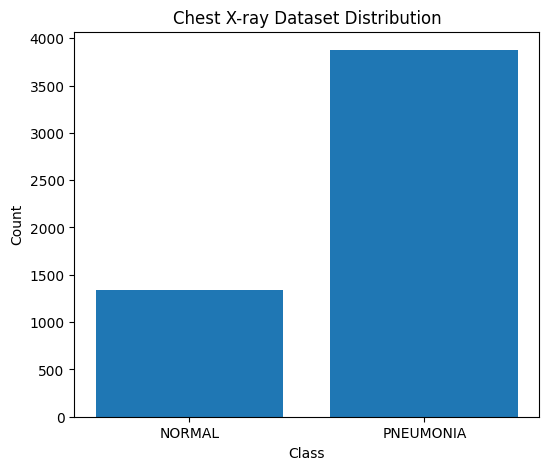

In [6]:
labels = ['NORMAL', 'PNEUMONIA']
counts = [len(train_normal),len(train_pn)]
plt.figure(figsize=(6,5))
plt.bar(labels,counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Chest X-ray Dataset Distribution")
plt.show()

In [7]:
table = pd.DataFrame({'Class': labels,'Count': counts})

table

,Class,Count
0,NORMAL,1341
1,PNEUMONIA,3875


In [8]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)


In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.98)

pca_train = pca.fit_transform(xtrain)

pca_test = pca.transform(xtest)

print(pca_train.shape)

(4172, 1417)


In [16]:
print(pca_test.shape)

(1044, 1417)


In [10]:
from sklearn.svm import SVC

rbf_model =SVC(kernel='rbf')
rbf_model.fit(pca_train,ytrain)
rbf_pred = rbf_model.predict(pca_test)


In [11]:
linear_model = SVC(kernel='linear')
linear_model.fit(pca_train,ytrain)
linear_pred=linear_model.predict(pca_test)


In [12]:
from sklearn.metrics import (accuracy_score,f1_score,confusion_matrix)

def evaluate_model(y_true,y_pred):
    accuracy = accuracy_score(y_true,y_pred)
    f1 = f1_score(y_true,y_pred)
    cm = confusion_matrix(y_true,y_pred)
    sensitivity = (cm[1,1] /(cm[1,1] + cm[1,0]))
    specificity = (cm[0,0] /(cm[0,0] + cm[0,1]))
    return (accuracy,f1,sensitivity,specificity)


In [13]:
#Evaluating the results of rbf model and linear model
rbf_results = evaluate_model(ytest,rbf_pred)
linear_results = evaluate_model(ytest,linear_pred)

print("RBF Results")
print("Accuracy:", rbf_results[0])
print("F1 Score:", rbf_results[1])
print("Sensitivity:", rbf_results[2])
print("Specificity:", rbf_results[3])

print("\n")

print("Linear Results")
print("Accuracy:", linear_results[0])
print("F1 Score:", linear_results[1])
print("Sensitivity:", linear_results[2])
print("Specificity:", linear_results[3])



RBF Results
Accuracy: 0.9683908045977011
F1 Score: 0.9788053949903661
Sensitivity: 0.9819587628865979
Specificity: 0.9291044776119403


Linear Results
Accuracy: 0.946360153256705
F1 Score: 0.9642401021711366
Sensitivity: 0.9729381443298969
Specificity: 0.8694029850746269


In [14]:
fractions = [0.2, 0.4, 0.6, 0.8]

rbf_acc = []

linear_acc = []

for frac in fractions:
    x_small, _, y_small, _ = train_test_split(pca_train,ytrain,train_size=frac,stratify=ytrain,
                                              random_state=42)

    
    # RBF
    

    rbf_temp = SVC(kernel='rbf')
    rbf_temp.fit(x_small,y_small)
    pred_rbf = rbf_temp.predict(pca_test)
    rbf_acc.append(accuracy_score(ytest,pred_rbf))

    # LINEAR
    

    linear_temp = SVC(kernel='linear')

    linear_temp.fit(x_small,y_small)

    pred_linear = linear_temp.predict(pca_test)

    linear_acc.append(accuracy_score(ytest,pred_linear))

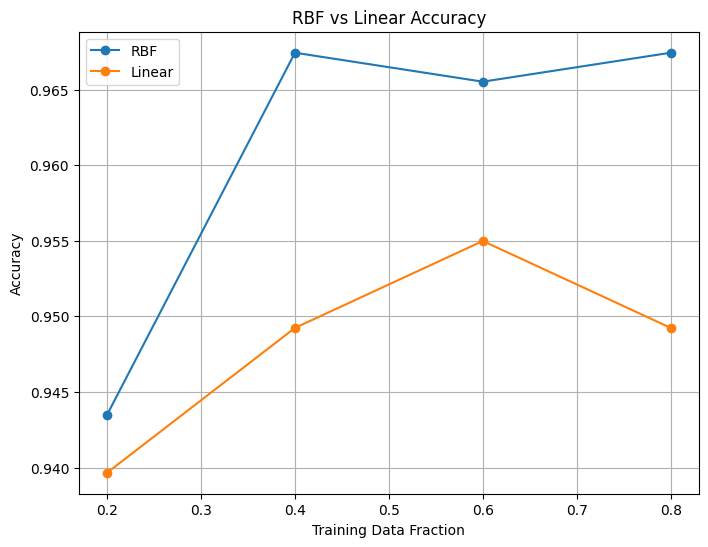

In [15]:
plt.figure(figsize=(8,6))

plt.plot(fractions,rbf_acc,marker='o',label='RBF')

plt.plot(fractions,linear_acc,marker='o',label='Linear')

plt.xlabel("Training Data Fraction")

plt.ylabel("Accuracy")

plt.title("RBF vs Linear Accuracy")

plt.legend()

plt.grid(True)

plt.show()